In [1]:
import numpy as np
import matplotlib.pyplot as plt
import graphviz
from pprint import pprint
import copy

import aux

# Set the seed for random generations
np.random.seed(12345)

Here I try to recreate the Perceptron architecture which implements the XOR gate (see notes on One Note) 

In [2]:
# I try to create a class for the NN
class Network:
    """
    Class for a generic neural network, defined by 
    - 2 input neurons, 1 output neuron
    - S: # of intra neurons.
    - Theta: threshold value.
    - J: connectivity matrix.
    """
    def __init__(self):
        self.S = 2      # Initialize with one intra neuron
        self.Theta = np.zeros(2+self.S+1)   # I instantiate a threshold value for each neuron, even the input, just for consistency of the indexes      
        self.J = self.initJ()
        self.activation = lambda x, theta: 0 if x < theta else 1    # activation function (if x = theta -> returns 1)
        self.neurons = np.zeros(2+self.S+1) # container for storing the values of the neurons
        self.fitness = None     # Initialize it to None for avoiding recomputation
        self.C = self.initJ()      # connectivity matrix (PER ORA USO INITJ())
        
    def initJ(self):            # QUESTO VA POI FATTO MEGLIO
        # Define the weight matrix J0_ij
        J0 = np.ones((2+self.S+1,2+self.S+1)) # Initialized all to one, so all connnected
        for j in range(len(J0)):            # First, impose on J0 that the elements on the diagonal must be zero
            J0[j,j] = 0.
        J0[0,1] = 0.            # Impose on the connectiviy matrix the fact that nuerons on the same layer cannot be connected 
        J0[1,0] = 0.
        for i in range(2, 2 + self.S):
            for j in range(2, 2 + self.S):
                J0[i, j] = 0. 
        J0[-1,0] = 0.           # ONLY FOR PXOR: I impose that there must not be direct links from input to output
        J0[-1,1] = 0.
        J0[0,-1] = 0.
        J0[1,-1] = 0.
        return J0
    
    def generate(self,par:dict):
        """Generate a random network.
        Args:
            par (dict, optional): parameters of the generation.
        """
        # ONLY FOR PXOR: i don't generate S, since it's fixed to 2
        self.Theta = np.random.uniform(par['Theta_range'][0],par['Theta_range'][1],2+self.S+1) # Generate the set of thresholds, Theta
        self.J = self.initJ() * np.random.uniform(par['J_range'][0],par['J_range'][1],(2+self.S+1)**2).reshape((2+self.S+1,2+self.S+1))   # Generate the weight matrix, J
        self.neurons = np.random.choice(np.array([0.0,1.0]),2+self.S+1)     # Initialize the values of the neurons (the lenght of this array depends on S)
        self.C = self.initJ() * np.random.choice([0,1],(2+self.S+1)**2).reshape((2+self.S+1,2+self.S+1))    # I SHOULD MAKE IT SYMMETRIC    
        self.compute_fitness(par)               # Already compute the fitness value of the network
        
    def ff(self,input:list,verb:int=0): # feed-forward
        """Compute the output of the network by feed-forward, given an input.
        Args:
            input (list): input to the network. Supported inputs are [0,0];[0,1];[1,0];[1,1].
            verb (int,optional): verbosity. If > 0, returns the value of each neuron. Default to 0.
        Returns:
            output (int): output of the network.
        """
        self.neurons[0:2] = input   # set the value of the first two neurons to the input value
        for neuron in range(2,2+self.S+1):    # compute the value of the intra neurons by feed forward
            self.neurons[neuron] = self.C[neuron,0] * self.J[neuron,0] * self.neurons[0] + self.C[neuron,1] * self.J[neuron,1] * self.neurons[1]   # I refer to the lower triangle of the matrix J
            self.neurons[neuron] = self.activation(self.neurons[neuron],self.Theta[neuron])     # Activation
        out = 0.        # Initialize a variable for containing the value of the output neuron 
        for neuron in range(0,2+self.S+1):  # compute the value of the ouput
            out += self.C[-1,neuron] * self.J[-1,neuron] * self.neurons[neuron]     # Add each neuron's weighted contribution to the output
        self.neurons[-1] = self.activation(out,self.Theta[-1])     # activation
        output = self.neurons[-1]
        if verb > 0:
            return self.neurons
        return output
        
    def compute_fitness(self,par:dict):
        """Compute the output of the network and from that the fitness value 
            and with that updates the network's fitness value.
        Args:
            par (dict): parameters of the generation.
        """
        if self.fitness == None:        # I need this check, bc otherwise I risk of adding fitness over fitness
            self.fitness = 0.           # This is to avoid type conflict and to make sure that I'm not computing the fitness of a network that already has it
            for i,input in enumerate(par['input_set']):
                output = self.ff(input)
                squared_dist = np.abs(1-(par['target_set'][i] - output))     # square distance between network output and target (theoretical) output
                #squared_cost = (np.sum([0 if np.isclose(j, 0.,atol=1e-2) else 1 for j in self.J.flatten()])/2)**2  
                squared_cost = np.sum(1-self.C.flatten())/2      # QUA CALCOLO IL COST SOLO SULLA PRESENZA O ASSENZA DI LINK
                self.fitness += (squared_dist + squared_cost)**2 # ONLY FOR PXOR: I don't use the cost
            self.fitness /= len(par['input_set'])    # normalize over the inputs

In [3]:
# Define the set of parameters
par = {'Sk_range': [1,2,3,4,5],  # define the possible value for Sk
       'Theta_range': [-1,+1],     # define the possible value for Theta
       'J_range': [-1,+1],  # define the possible value for J
       'input_set':[[0,0],[0,1],[1,0],[1,1]],    # Set of inputs
       'target_set': [0.0,1.0,1.0,0.0],    # set of outputs for the XOR gate 
       'mutation_ratio': 0.8,             # set the ratio of mutated solutions over the whole number of individuals that have to be generate after a selection. Who is not mutated is random 
       'S_mutation_radius': 0,            # ONLY FOR PXOR: no mutation on S
       'Theta_mutation_radius': 1/10,
       'J_mutation_radius': 1/10,
       'N_sol': 100,                       # Set the number of solutions 
       'n_iter': 500}                                       

In [4]:
def evolution(par:dict):
    # Generate the solutions
    solutions = []
    for _ in range(par['N_sol']):
        # Generate a solution
        n = Network()
        n.generate(par)     # already computes also the fitness value
        solutions.append(n)
    solutions = np.array(solutions)
    # Initiate some container for statistic
    Fmean_values = []
    S_values = []
    
    ##  EVOLUTION
    for iter in range(par['n_iter']):
        print(f'Iteration #{iter}...')
        # Compute the mean fitness
        mean_fit = np.sum([sol.fitness for sol in solutions]) / par['N_sol']    # Here I don't have to divide also by 4, because I've already done it in the compute_fitness method
        # Discard elements in sol whose fitness value is below average 
        solutions = np.array([sol for sol in solutions if sol.fitness >= mean_fit])     
        # Compute the number of discarded elements, m
        m = par['N_sol'] - len(solutions)
        # Extract the parents between the survivors (here we can either take them random or take the fittest survivors)
        n_parents = int(np.floor(par['mutation_ratio'] * m))
        parents_idx = np.random.randint(low=0,high=int(len(solutions)),size=n_parents,dtype=int)
        parents = solutions[parents_idx]
        # Firstly, instantiate the offsprings as copies of the parents
        #offspring = [copy.deepcopy(parent) for parent in parents]     # I must use copy.deepcopy because otherwise I modify both objects when I modify one
        offspring = []
        for parent in parents:
            offspring.append(copy.deepcopy(parent))
        offspring = np.array(offspring)
        print(f'# of childs: {len(offspring)}')
        
        ## MUTATION
        # Now, mutate S first
        for i,child in enumerate(offspring):
            # Mutate C
            C0 = child.initJ()     # I utilize the method initJ() to create a new C given the new S              
            # mutate (I mutate also the newly generated thetas)
            mutationC = np.random.choice([0,1], len(child.C)**2).reshape(child.C.shape)   # generate the mutation radius 
            # Apply the mutation
            child.C = C0 * mutationC
            # Now mutate the thresholds 
            # mutate theta (I mutate also the newly generated thetas)
            mutationTheta = np.random.uniform(par['Theta_range'][0]*par['Theta_mutation_radius'], 
                                        par['Theta_range'][1]*par['Theta_mutation_radius'], len(child.Theta))   # generate the mutation radius 
            child.Theta += mutationTheta
            # Check the boundary conditions for Theta
            for theta in child.Theta:
                if theta < min(par['Theta_range']):
                    theta = min(par['Theta_range'])
                if theta > max(par['Theta_range']):
                    theta = max(par['Theta_range'])     
            # Mutate J
            J0 = child.initJ()     # I utilize the method initJ() to create a new J given the new S              
            # mutate (I mutate also the newly generated thetas)
            mutationJ = np.random.uniform(par['J_range'][0]*par['J_mutation_radius'], 
                                        par['J_range'][1]*par['J_mutation_radius'], len(child.J)**2).reshape(child.J.shape)   # generate the mutation radius 
            # Apply the mutation
            child.J += mutationJ
            # multiplicate with J0 to set to 0 where necessary by the conditions         
            child.J *= J0
            # Check the boundary conditions for J
            for row in child.J:
                for j in row:
                    if j < min(par['J_range']):
                        j = min(par['J_range'])
                    if j > max(par['J_range']):
                        j = max(par['J_range'])        
            # Already compute the fitness value of the network
            child.fitness = None            # I have to first set it to None beacuse child inherits self.fitness from the parent
            child.compute_fitness(par)      # Here I have to do it explicitly because I'm not generating the Network object through Network.generate()       
        # Add the offsprings generated by mutation to the survived solutions
        solutions = np.concatenate([solutions,offspring])
        # Randomly generate the remaining individuals (population must be constant)
        n_generation = m - n_parents
        generated = []
        for _ in range(n_generation):
            # Generate a solution
            n = Network()
            n.generate(par)             # already with computed fitness
            generated.append(n)
        generated = np.array(generated)     # transform it to a np.ndarray
        # Add the randomly generated solutions to the other solutions
        solutions = np.concatenate([solutions,generated])
        # Add a check for conservation of population
        if len(solutions) != par['N_sol']:
            msg = f'The solutions population was not conserved. Expected {par['N_sol']}, but instead got {len(solutions)}.'
            aux.checkpoint(True,msg=msg,stop=True)    
        # Shuffle the order of the solutions for good measure
        np.random.shuffle(solutions)
        # Statistic 
        meanS = np.mean([sol.S for sol in solutions])
        Fmean_values.append(mean_fit)
        S_values.append(meanS)
    return solutions, Fmean_values, S_values


In [5]:
solutions, Fmean_values, S_values = evolution(par)

Iteration #0...
# of childs: 42
Iteration #1...
# of childs: 46
Iteration #2...
# of childs: 32
Iteration #3...
# of childs: 48
Iteration #4...
# of childs: 39
Iteration #5...
# of childs: 31
Iteration #6...
# of childs: 27
Iteration #7...
# of childs: 25
Iteration #8...
# of childs: 20
Iteration #9...
# of childs: 17
Iteration #10...
# of childs: 13
Iteration #11...
# of childs: 52
Iteration #12...
# of childs: 44
Iteration #13...
# of childs: 39
Iteration #14...
# of childs: 32
Iteration #15...
# of childs: 25
Iteration #16...
# of childs: 39
Iteration #17...
# of childs: 32
Iteration #18...
# of childs: 28
Iteration #19...
# of childs: 26
Iteration #20...
# of childs: 34
Iteration #21...
# of childs: 29
Iteration #22...
# of childs: 30
Iteration #23...
# of childs: 26
Iteration #24...
# of childs: 27
Iteration #25...
# of childs: 26
Iteration #26...
# of childs: 24
Iteration #27...
# of childs: 23
Iteration #28...
# of childs: 22
Iteration #29...
# of childs: 20
Iteration #30...
# o

In [6]:
for sol in solutions:
    print(sol.C)

[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0.]]
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0.]]
[[0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]
[[0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0.]]
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]
[[0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]
[[0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0.]]
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0.]]
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]
[[0. 0. 1. 1. 0.]
 [0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 1.]
 [0. 0. 1. 0. 0.]]
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0.]]

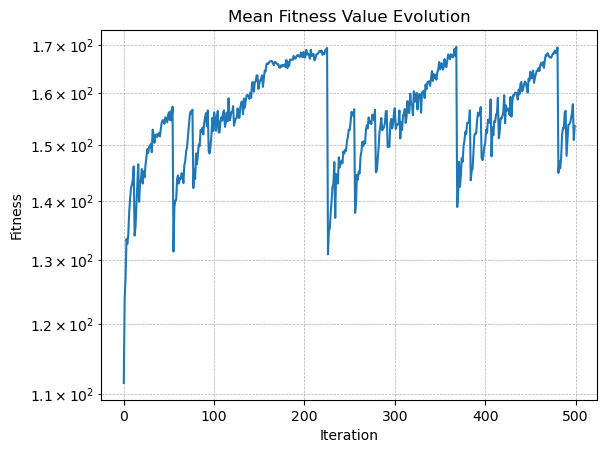

In [7]:
plt.plot(Fmean_values)
plt.title('Mean Fitness Value Evolution')
plt.xlabel('Iteration')
plt.ylabel('Fitness')
#plt.xscale('log')
plt.yscale('log')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

In [8]:
print(f'Final mean fitness: {Fmean_values[-1]}')
for i,sol in enumerate(solutions):
    print(f'Solution #{i}...')
    print(f'Fitness: {sol.fitness}')
    print(f'S: {sol.S}')
    for input in par['input_set']:
        print(sol.ff(input))

Final mean fitness: 153.5975
Solution #0...
Fitness: 182.5
S: 2
1.0
1.0
1.0
1.0
Solution #1...
Fitness: 169.25
S: 2
1.0
1.0
1.0
1.0
Solution #2...
Fitness: 182.5
S: 2
1.0
1.0
1.0
1.0
Solution #3...
Fitness: 156.5
S: 2
1.0
1.0
1.0
1.0
Solution #4...
Fitness: 182.5
S: 2
1.0
1.0
1.0
1.0
Solution #5...
Fitness: 169.25
S: 2
1.0
1.0
1.0
1.0
Solution #6...
Fitness: 169.25
S: 2
1.0
1.0
1.0
1.0
Solution #7...
Fitness: 182.5
S: 2
1.0
1.0
1.0
1.0
Solution #8...
Fitness: 182.5
S: 2
1.0
1.0
1.0
1.0
Solution #9...
Fitness: 121.25
S: 2
1.0
1.0
1.0
1.0
Solution #10...
Fitness: 182.5
S: 2
1.0
1.0
1.0
1.0
Solution #11...
Fitness: 169.25
S: 2
1.0
1.0
1.0
1.0
Solution #12...
Fitness: 182.5
S: 2
1.0
1.0
1.0
1.0
Solution #13...
Fitness: 110.5
S: 2
1.0
1.0
1.0
1.0
Solution #14...
Fitness: 182.5
S: 2
1.0
1.0
1.0
1.0
Solution #15...
Fitness: 182.5
S: 2
1.0
1.0
1.0
1.0
Solution #16...
Fitness: 182.5
S: 2
1.0
1.0
1.0
1.0
Solution #17...
Fitness: 182.5
S: 2
1.0
1.0
1.0
1.0
Solution #18...
Fitness: 182.5
S: 2
1.0


In [9]:
sol = solutions[0]
pprint(vars(sol))

{'C': array([[0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0.]]),
 'J': array([[-0.        , -0.        , -0.09047277,  0.63143882, -0.        ],
       [-0.        ,  0.        ,  0.59592072,  0.02768669,  0.        ],
       [ 0.24835618, -0.66268768,  0.        , -0.        , -0.63101476],
       [ 0.41584773, -0.83998459, -0.        ,  0.        , -0.32226485],
       [ 0.        , -0.        , -0.44212601, -0.03280885,  0.        ]]),
 'S': 2,
 'Theta': array([-0.17558597,  0.41297846,  0.08195005, -0.78780754, -0.78126303]),
 'activation': <function Network.__init__.<locals>.<lambda> at 0x7f7182e64e00>,
 'fitness': 182.5,
 'neurons': array([1., 1., 0., 1., 1.])}


In [10]:
sol.J[2,0]

0.24835618216138416